# Olist E-Commerce Analytics — Data Exploration

## Objective

This notebook performs exploratory data analysis and data-quality assessment
of the Olist Brazilian e-commerce dataset.

The analysis covers:

- Dataset structure
- Data types
- Missing values
- Duplicate records
- Primary-key uniqueness
- Referential integrity
- Date ranges
- Numerical distributions
- Categorical distributions
- Business data-quality checks

The purpose is to understand the raw data before building the ETL pipeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
REPORTS_PATH = PROJECT_ROOT / "reports"

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Processed data path:", PROCESSED_DATA_PATH)
print("Reports path:", REPORTS_PATH)

Project root: e:\Learning\Projects\Olist-Ecom
Raw data path: e:\Learning\Projects\Olist-Ecom\data\raw
Processed data path: e:\Learning\Projects\Olist-Ecom\data\processed
Reports path: e:\Learning\Projects\Olist-Ecom\reports


In [4]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Raw data folder not found: {RAW_DATA_PATH}")
else:
    print("Raw data folder found.")

Raw data folder found.


In [5]:
csvFiles = sorted(RAW_DATA_PATH.glob("*.csv"))
# print(RAW_DATA_PATH)
print(f"Number of CSV files found: {len(csvFiles)}")
# print(csvFiles)
for file in csvFiles:
    print(file.name)

Number of CSV files found: 9
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [6]:
DATA_FILES = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv"
}

print("Dataset configuration created.")

Dataset configuration created.


In [7]:
# print(RAW_DATA_PATH)
dataset = {}
for name, filename in DATA_FILES.items():
    filePath = RAW_DATA_PATH / filename
    if not filePath.exists():
        raise FileNotFoundError(f"Missing File: {filePath}")
    dataset[name] = pd.read_csv(filePath)
print("All datasets loaded Successfully!!!")

All datasets loaded Successfully!!!


In [8]:
datasetsShape = []
for name, df in dataset.items():
    datasetsShape.append({
        'dataset': name,
        'rows': df.shape[0],
        'columns': df.shape[1]
    })
shapeDF = pd.DataFrame(datasetsShape)

shapeDF

,dataset,rows,columns
0,customers,99441,5
1,geolocation,1000163,5
2,order_items,112650,7
3,order_payments,103886,5
4,order_reviews,99224,7
5,orders,99441,8
6,products,32951,9
7,sellers,3095,4
8,category_translation,71,2


In [9]:
for name, df in dataset.items():
    print('-'*30)
    print(f"{name.upper()}")
    print('Column')
    for col in df.columns:
        print(f" - {col}")

------------------------------
CUSTOMERS
Column
 - customer_id
 - customer_unique_id
 - customer_zip_code_prefix
 - customer_city
 - customer_state
------------------------------
GEOLOCATION
Column
 - geolocation_zip_code_prefix
 - geolocation_lat
 - geolocation_lng
 - geolocation_city
 - geolocation_state
------------------------------
ORDER_ITEMS
Column
 - order_id
 - order_item_id
 - product_id
 - seller_id
 - shipping_limit_date
 - price
 - freight_value
------------------------------
ORDER_PAYMENTS
Column
 - order_id
 - payment_sequential
 - payment_type
 - payment_installments
 - payment_value
------------------------------
ORDER_REVIEWS
Column
 - review_id
 - order_id
 - review_score
 - review_comment_title
 - review_comment_message
 - review_creation_date
 - review_answer_timestamp
------------------------------
ORDERS
Column
 - order_id
 - customer_id
 - order_status
 - order_purchase_timestamp
 - order_approved_at
 - order_delivered_carrier_date
 - order_delivered_customer_da

Check data types

In [10]:
for name, df in dataset.items():
    print("-"*30)
    print(f"{name.upper()} DataFrame:")
    print(f"{df.dtypes}")
    


------------------------------
CUSTOMERS DataFrame:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object
------------------------------
GEOLOCATION DataFrame:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object
------------------------------
ORDER_ITEMS DataFrame:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object
------------------------------
ORDER_PAYMENTS DataFrame:
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64

In [11]:
dataDictionary = []
# print(dataset)
for datasetName, df in dataset.items():
    for col in df.columns:
        dataDictionary.append({
            'dataset': datasetName,
            'columns': col,
            'dtype': str(df[col].dtype),
            'count': len(df[col]),
            'nullValues' : df[col].isna().sum(),
            'NullPercentage': df[col].isna().mean() * 100,
            'UniqueValues': df[col].nunique(dropna = True)
        })

dataDictionaryDF = pd.DataFrame(dataDictionary)

In [12]:
dataDictionaryDF

,dataset,columns,dtype,count,nullValues,NullPercentage,UniqueValues
0,customers,customer_id,str,99441,0,0.00,99441
1,customers,customer_unique_id,str,99441,0,0.00,96096
2,customers,customer_zip_code_prefix,int64,99441,0,0.00,14994
3,customers,customer_city,str,99441,0,0.00,4119
4,customers,customer_state,str,99441,0,0.00,27
5,geolocation,geolocation_zip_code_prefix,int64,1000163,0,0.00,19015
6,geolocation,geolocation_lat,float64,1000163,0,0.00,717360
7,geolocation,geolocation_lng,float64,1000163,0,0.00,717613
8,geolocation,geolocation_city,str,1000163,0,0.00,8011
9,geolocation,geolocation_state,str,1000163,0,0.00,27


In [13]:
missingSummary = []

for name, df in dataset.items():
    for column in df.columns:
        missingSummary.append({
            "dataset": name,
            "column": column,
            "missingCount": df[column].isna().sum(),
            "missingPercentage": df[column].isna().mean() * 100
        })

missingDF = pd.DataFrame(missingSummary)

missingDF = missingDF[
    missingDF["missingCount"] > 0
].sort_values(
    "missingPercentage",
    ascending=False
)


In [14]:
missingDF

,dataset,column,missingCount,missingPercentage
25,order_reviews,review_comment_title,87656,88.34
26,order_reviews,review_comment_message,58247,58.70
35,orders,order_delivered_customer_date,2965,2.98
39,products,product_name_lenght,610,1.85
38,products,product_category_name,610,1.85
40,products,product_description_lenght,610,1.85
41,products,product_photos_qty,610,1.85
34,orders,order_delivered_carrier_date,1783,1.79
33,orders,order_approved_at,160,0.16
42,products,product_weight_g,2,0.01


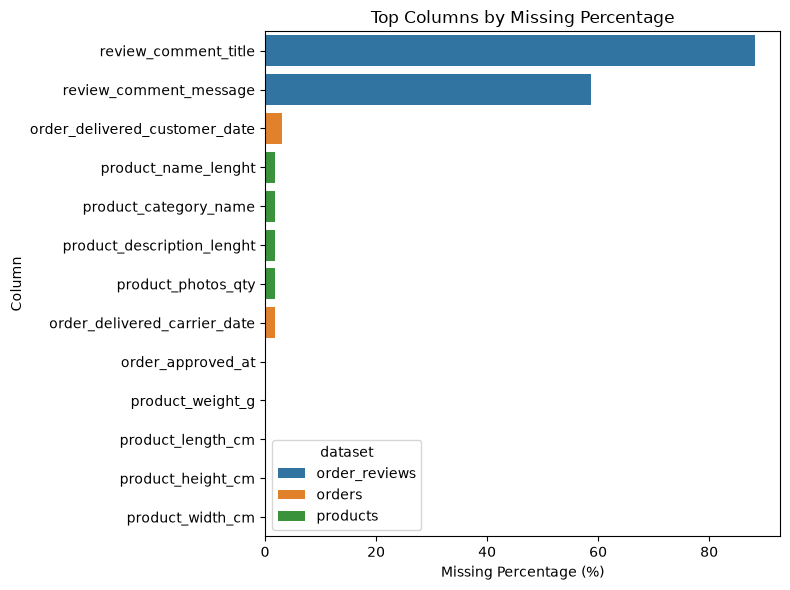

In [15]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=missingDF.head(20),
    x="missingPercentage",
    y="column",
    hue="dataset",
    dodge=False
)

plt.title("Top Columns by Missing Percentage")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

Duplicate Check

In [16]:
duplicateSummary = []
for name, df in dataset.items():
    duplicateCount = df.duplicated().sum()
    duplicateSummary.append({
        'dataset': name,
        'rows': len(df),
        'duplicatedRows' : duplicateCount,
        'duplicatePercentage': ((duplicateCount / len(df)) *100).round(2)
    })
duplicateDF = pd.DataFrame(duplicateSummary)
duplicateDF


,dataset,rows,duplicatedRows,duplicatePercentage
0,customers,99441,0,0.00
1,geolocation,1000163,261831,26.18
2,order_items,112650,0,0.00
3,order_payments,103886,0,0.00
4,order_reviews,99224,0,0.00
5,orders,99441,0,0.00
6,products,32951,0,0.00
7,sellers,3095,0,0.00
8,category_translation,71,0,0.00


In [17]:
for name, df in dataset.items():
    duplicateCount = df.duplicated().sum()
    
    if duplicateCount > 0:
        print(f"{name}: {duplicateCount} duplicate rows")

geolocation: 261831 duplicate rows


In [18]:
PRIMARY_KEYS = {
    "orders": ["order_id"],
    "customers": ["customer_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    'test': None,
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["order_id","review_id"],
    "category_translation": ["product_category_name"],
    "geolocation": None
}

In [19]:
for datasetName, keyColumns in PRIMARY_KEYS.items():
    
    if keyColumns is None:
        continue
    # print('hello',keyColumns)
    df = dataset[datasetName]
    
    duplicateKeys = df.duplicated(
        subset=keyColumns
    ).sum()
    
    print(
        f"{datasetName}: "
        f"{duplicateKeys} duplicate primary-key combinations"
    )

orders: 0 duplicate primary-key combinations
customers: 0 duplicate primary-key combinations
products: 0 duplicate primary-key combinations
sellers: 0 duplicate primary-key combinations
order_items: 0 duplicate primary-key combinations
order_payments: 0 duplicate primary-key combinations
order_reviews: 0 duplicate primary-key combinations
category_translation: 0 duplicate primary-key combinations


In [20]:
dataset['order_reviews']

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


Inspecting the order table

In [21]:
order = dataset['orders']
order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [22]:
order.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [23]:
order.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [24]:
order['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

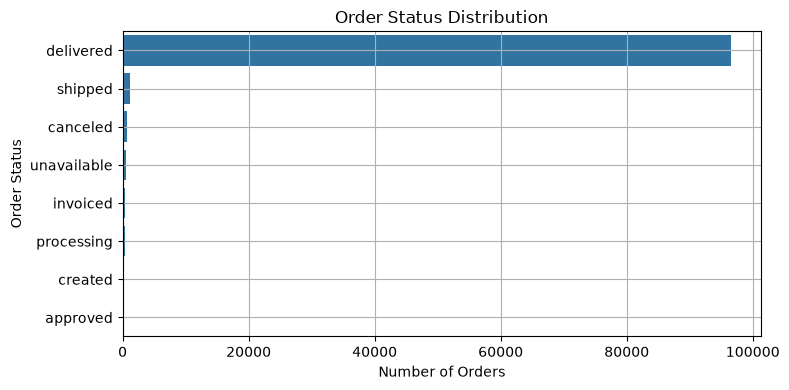

In [25]:
plt.figure(figsize=(8,4))
sns.countplot(
    data = order,
    y = 'order_status',
    order = order['order_status'].value_counts().index
)
plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")
plt.grid(True)
plt.tight_layout()
plt.show()

i want to check how many order have not order_delivered_customer_date?

In [26]:
order.groupby('order_status')['order_delivered_customer_date'].apply(
    lambda x: x.isna().sum()
)

order_status
approved          2
canceled        619
created           5
delivered         8
invoiced        314
processing      301
shipped        1107
unavailable     609
Name: order_delivered_customer_date, dtype: int64

In [27]:
order[
    (order['order_status'] == 'delivered') &
    (order['order_delivered_customer_date'].isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [28]:
print(f"OrderID's Duplicated: {order['order_id'].duplicated().sum()}")
print(f"OrderID's Uniques: {order['order_id'].nunique()}")

OrderID's Duplicated: 0
OrderID's Uniques: 99441


In [29]:
order[
    (order['order_status']=='delivered') &
    (order['order_delivered_customer_date'].notna())
    ].shape

(96470, 8)

In [30]:
deliveredMask = (
    (order['order_status']=='delivered') &
    (order['order_delivered_customer_date'].notna())
)

print(f"Delivered Mask Sum: {deliveredMask.sum()}")

Delivered Mask Sum: 96470


In [31]:
orderEDA = order.copy()
dateColumns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in dateColumns:
    orderEDA[col] = pd.to_datetime(orderEDA[col], errors='coerce')

orderEDA[dateColumns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [32]:
def dateMinMax(df ,columns):
    for col in columns:
        print(f"{col} Minimum {df[col].min()}")
        print(f"{col} Maximum {df[col].max()}")

dateMinMax(orderEDA,dateColumns)

order_purchase_timestamp Minimum 2016-09-04 21:15:19
order_purchase_timestamp Maximum 2018-10-17 17:30:18
order_approved_at Minimum 2016-09-15 12:16:38
order_approved_at Maximum 2018-09-03 17:40:06
order_delivered_carrier_date Minimum 2016-10-08 10:34:01
order_delivered_carrier_date Maximum 2018-09-11 19:48:28
order_delivered_customer_date Minimum 2016-10-11 13:46:32
order_delivered_customer_date Maximum 2018-10-17 13:22:46
order_estimated_delivery_date Minimum 2016-09-30 00:00:00
order_estimated_delivery_date Maximum 2018-11-12 00:00:00


In [33]:
# orderEDA['order_purchase_timestamp'].dtypes
orderEDA['delivery_days'] = (
    orderEDA['order_delivered_customer_date']
    - orderEDA['order_purchase_timestamp']
).dt.total_seconds() / (24*60*60)

orderEDA['delivery_days'].head()

0    8.44
1   13.78
2    9.39
3   13.21
4    2.87
Name: delivery_days, dtype: float64

In [34]:
dateMinMax(orderEDA,['delivery_days'])

delivery_days Minimum 0.5334143518518518
delivery_days Maximum 209.6286111111111


In [35]:
orderEDA['delivery_delay_days'] = (
    orderEDA['order_delivered_customer_date']
    - orderEDA['order_estimated_delivery_date']
).dt.total_seconds() / (24*60*60)

dateMinMax(orderEDA,['delivery_delay_days'])

delivery_delay_days Minimum -146.0161226851852
delivery_delay_days Maximum 188.97508101851852


In [36]:
lateDeliveredOrder = orderEDA.loc[
    deliveredMask & (orderEDA["delivery_delay_days"] > 0)
]
print(f"Shape Of LateDeliveryOrder {lateDeliveredOrder.shape}")

lateDeliveredRate = (
            (len(lateDeliveredOrder)) / (deliveredMask.sum())
)*100

print(lateDeliveredRate)

Shape Of LateDeliveryOrder (7826, 10)
8.112366538820359


CustomerInspection

In [37]:
customer = dataset['customers']
customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [38]:
print(f"Customer Shape {customer.shape}")
print(f"Customer Columns {customer.columns}")
print("Unique customer IDs:", customer["customer_unique_id"].nunique())
print("Customer IDs:", customer["customer_id"].nunique())

customerOrderCounts = (
    customer["customer_unique_id"]
    .value_counts()
)

Customer Shape (99441, 5)
Customer Columns Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')
Unique customer IDs: 96096
Customer IDs: 99441


In [39]:
customerOrderCounts = (
    customer["customer_unique_id"]
    .value_counts()
)

customerOrderCounts

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
1a29b476fee25c95fbafc67c5ac95cf8     1
d52a67c98be1cf6a5c84435bd38d095d     1
e9f50caf99f032f0bf3c55141f019d99     1
73c2643a0a458b49f58cea58833b192e     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [40]:
(customerOrderCounts > 1).sum()

np.int64(2997)

In [41]:
customer['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [42]:
# Does every `customer_id` in Order exist in Customers
orderEDA['customer_id'].isin(customer['customer_id']).value_counts()

customer_id
True    99441
Name: count, dtype: int64

In [43]:
orderCustomerEDA = orderEDA.merge(
    customer[[
        "customer_id",
        "customer_state"
    ]],
    on="customer_id",
    how='left'
)

In [44]:
orderCustomerEDA['customer_state'].value_counts().head()
# customer['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

In [45]:

(orderCustomerEDA
 .groupby('customer_state')['delivery_days']
 .agg(['count','mean'])
 .sort_values('count', ascending= False)
 )
# orderCustomerEDA.columns#

,count,mean
customer_state,,
SP,40495,8.76
RJ,12353,15.31
MG,11355,12.01
RS,5344,15.30
PR,4923,11.99
SC,3547,14.96
BA,3256,19.34
DF,2080,12.97
ES,1995,15.79


In [46]:
(orderCustomerEDA.loc[
    orderCustomerEDA['delivery_days'].isna(),
    ['customer_state', 'delivery_days']]
)

,customer_state,delivery_days
6,RS,NaN
44,SP,NaN
103,SC,NaN
128,SP,NaN
154,MG,NaN
...,...,...
99283,SP,NaN
99313,SP,NaN
99347,SP,NaN
99348,RJ,NaN


In [47]:
stateDeilvery = (
    orderCustomerEDA.loc[deliveredMask]
    .groupby('customer_state')['delivery_days']
    .agg(["count", "mean", "median"])
    .sort_values('mean', ascending= False)
)
stateDeilvery

,count,mean,median
customer_state,,,
RR,41,29.39,25.01
AP,67,27.19,24.35
AM,145,26.43,25.88
AL,397,24.54,22.33
PA,946,23.77,21.08
MA,717,21.57,19.19
SE,335,21.52,18.01
CE,1279,21.27,18.21
AC,80,21.04,18.36


In [48]:
stateLateDelivery = (orderCustomerEDA.loc[deliveredMask]
                     .groupby('customer_state')
                     .agg(
                         deliveredOrder = ('order_id','count'),
                         lateOrder = ('delivery_delay_days', lambda x: (x>0).sum())
                     )
                    )

# orderCustomerEDA.columns

stateLateDelivery

,deliveredOrder,lateOrder
customer_state,,
AC,80,3
AL,397,95
AM,145,6
AP,67,3
BA,3256,457
CE,1279,196
DF,2080,147
ES,1995,244
GO,1957,160


In [49]:
stateLateDelivery['lateRate'] = (
    stateLateDelivery['lateOrder'] / stateLateDelivery['deliveredOrder']
)*100

stateLateDelivery

,deliveredOrder,lateOrder,lateRate
customer_state,,,
AC,80,3,3.75
AL,397,95,23.93
AM,145,6,4.14
AP,67,3,4.48
BA,3256,457,14.04
CE,1279,196,15.32
DF,2080,147,7.07
ES,1995,244,12.23
GO,1957,160,8.18


In [3]:
orderItems = dataset['order_items']
orderItems.head()

NameError: name 'dataset' is not defined

In [51]:
print('OrderItem - Order Id: Duplicated:', orderItems['order_id'].duplicated().sum())
print('OrderItem - OrderItemId: Duplicated:', orderItems['order_item_id'].duplicated().sum())
print('Total Data: ', len(orderItems))

OrderItem - Order Id: Duplicated: 13984
OrderItem - OrderItemId: Duplicated: 112629
Total Data:  112650


In [52]:
orderItems.duplicated(
    subset=['order_id', 'order_item_id']
).sum()

np.int64(0)

In [53]:
orderItems['shipping_limit_date'] = pd.to_datetime(orderItems['shipping_limit_date'])

In [54]:
orderItems.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

In [55]:
print('Price == 0:',(orderItems["price"] == 0).sum())
print('freight value < 0:',(orderItems["freight_value"] < 0).sum())
orderItems['item_total'] = (orderItems['price'] + orderItems['freight_value'])
orderItems[[
    "order_id",
    "price",
    "freight_value",
    "item_total"
]].head()

Price == 0: 0
freight value < 0: 0


,order_id,price,freight_value,item_total
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [56]:
orderItems["order_id"].isin(orderEDA["order_id"]).value_counts()

order_id
True    112650
Name: count, dtype: int64

In [57]:
itemsPerOrder = (
    orderItems.groupby("order_id")["order_item_id"]
    .count()
)

itemsPerOrder

order_id
00010242fe8c5a6d1ba2dd792cb16214    1
00018f77f2f0320c557190d7a144bdd3    1
000229ec398224ef6ca0657da4fc703e    1
00024acbcdf0a6daa1e931b038114c75    1
00042b26cf59d7ce69dfabb4e55b4fd9    1
                                   ..
fffc94f6ce00a00581880bf54a75a037    1
fffcd46ef2263f404302a634eb57f7eb    1
fffce4705a9662cd70adb13d4a31832d    1
fffe18544ffabc95dfada21779c9644f    1
fffe41c64501cc87c801fd61db3f6244    1
Name: order_item_id, Length: 98666, dtype: int64

In [ ]:
orderWithoutItem = orderEDA[~orderEDA['order_id'].isin(orderItems['order_id'])]
len(orderWithoutItem)
# orderWithoutItem.columns
orderWithoutItem['order_status'].value_counts()

NameError: name 'orderEDA' is not defined

In [59]:
# orderItems.columns
# orderItems['item_total']
orderTotals = (
    orderItems.groupby("order_id")
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        total_value=("item_total", "sum")
    )
)

In [2]:
orderTotals = orderTotals.join(
    itemsPerOrder.rename("item_count")
)

orderTotals.head()

NameError: name 'orderTotals' is not defined

In [61]:
orderTotals

,total_price,total_freight,total_value,item_count
order_id,,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19,1
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83,1
000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87,1
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78,1
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04,1
...,...,...,...,...
fffc94f6ce00a00581880bf54a75a037,299.99,43.41,343.40,1
fffcd46ef2263f404302a634eb57f7eb,350.00,36.53,386.53,1
fffce4705a9662cd70adb13d4a31832d,99.90,16.95,116.85,1


In [62]:
orderItems.loc[orderItems['order_id']=='8272b63d03f5f79c56e9e4120aec44ef',
               ['order_item_id','price','freight_value','item_total']]

,order_item_id,price,freight_value,item_total
57297,1,1.20,7.89,9.09
57298,2,1.20,7.89,9.09
57299,3,1.20,7.89,9.09
57300,4,1.20,7.89,9.09
57301,5,1.20,7.89,9.09
57302,6,1.20,7.89,9.09
57303,7,1.20,7.89,9.09
57304,8,1.20,7.89,9.09
57305,9,1.20,7.89,9.09
57306,10,1.20,7.89,9.09


In [63]:
orderCustomerSaleEDA = (orderCustomerEDA.merge(
    orderTotals,
    on= 'order_id',
    how = 'left'
))
type(orderCustomerSaleEDA)

pandas.DataFrame

In [64]:
orderCustomerSaleEDA[
    ["total_price", "total_freight", "total_value", "item_count"]
].isna().sum()

total_price      775
total_freight    775
total_value      775
item_count       775
dtype: int64

In [65]:
orderCustomerSaleEDA['purchaseMonth'] = orderCustomerSaleEDA['order_purchase_timestamp'].dt.to_period("M")

# orderCustomerSaleEDA[['order_id','purchaseMonth','order_purchase_timestamp']]

orderCustomerMonthlySaleEDA = (
    orderCustomerSaleEDA
    .groupby('purchaseMonth')
    .agg(
        orders=("order_id", "nunique"),
        product_sales=("total_price", lambda x: x.sum(min_count=1)),
        freight=("total_freight", lambda x: x.sum(min_count=1)),
        total_value=("total_value", lambda x: x.sum(min_count=1))
        )
    .reset_index()
    )

orderCustomerMonthlySaleEDA

# monthlyDeliveredOrder.tail()
# orderCustomerSaleEDA.columns


,purchaseMonth,orders,product_sales,freight,total_value
0,2016-09,4,267.36,87.39,354.75
1,2016-10,324,"49,507.66","7,301.18","56,808.84"
2,2016-12,1,10.90,8.72,19.62
3,2017-01,800,"120,312.87","16,875.62","137,188.49"
4,2017-02,1780,"247,303.02","38,977.60","286,280.62"
5,2017-03,2682,"374,344.30","57,704.29","432,048.59"
6,2017-04,2404,"359,927.23","52,495.01","412,422.24"
7,2017-05,3700,"506,071.14","80,119.81","586,190.95"
8,2017-06,3245,"433,038.60","69,924.44","502,963.04"
9,2017-07,4026,"498,031.48","86,940.14","584,971.62"


In [66]:
orderCustomerMonthlySaleEDA["orderGrowthPCT"] = (
    orderCustomerMonthlySaleEDA["orders"].pct_change() * 100
)

In [67]:
type(orderCustomerMonthlySaleEDA)

pandas.DataFrame

In [68]:
allMonth = pd.period_range(
    start=orderCustomerMonthlySaleEDA['purchaseMonth'].min(),
    end=orderCustomerMonthlySaleEDA['purchaseMonth'].max(),
    freq='M'
)
type(allMonth)

pandas.PeriodIndex

In [69]:
# orderCustomerMonthlySaleEDA
# allMonth

orderCustomerMonthlySaleEDA = (
    orderCustomerMonthlySaleEDA
    .set_index("purchaseMonth")
    .reindex(allMonth)
    .rename_axis("purchaseMonth")
    .reset_index()
)
orderCustomerMonthlySaleEDA

,purchaseMonth,orders,product_sales,freight,total_value,orderGrowthPCT
0,2016-09,4.00,267.36,87.39,354.75,NaN
1,2016-10,324.00,"49,507.66","7,301.18","56,808.84","8,000.00"
2,2016-11,NaN,NaN,NaN,NaN,NaN
3,2016-12,1.00,10.90,8.72,19.62,-99.69
4,2017-01,800.00,"120,312.87","16,875.62","137,188.49","79,900.00"
5,2017-02,"1,780.00","247,303.02","38,977.60","286,280.62",122.50
6,2017-03,"2,682.00","374,344.30","57,704.29","432,048.59",50.67
7,2017-04,"2,404.00","359,927.23","52,495.01","412,422.24",-10.37
8,2017-05,"3,700.00","506,071.14","80,119.81","586,190.95",53.91
9,2017-06,"3,245.00","433,038.60","69,924.44","502,963.04",-12.30


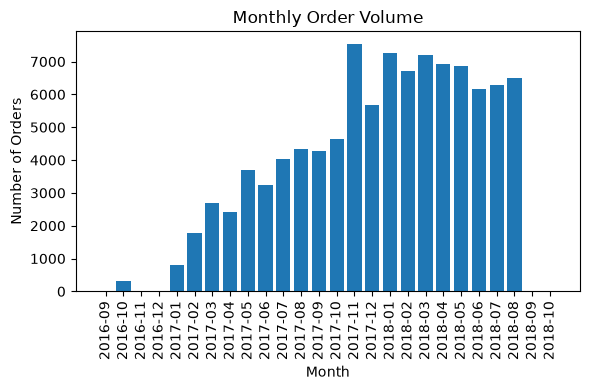

In [70]:
plt.figure(figsize=(6,4))
plt.bar(
    orderCustomerMonthlySaleEDA['purchaseMonth'].astype('str'),
    orderCustomerMonthlySaleEDA['orders'],
)
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [71]:
orderCustomerMonthlySaleEDA["year"] = orderCustomerMonthlySaleEDA["purchaseMonth"].dt.year
yearlySales = (
    orderCustomerMonthlySaleEDA.groupby("year")
    .agg(
        orders=("orders", "sum"),
        product_sales=("product_sales", "sum"),
        freight=("freight", "sum"),
        total_value=("total_value", "sum")
    )
    .reset_index()
)

yearlySales

,year,orders,product_sales,freight,total_value
0,2016,329.00,"49,785.92","7,397.29","57,183.21"
1,2017,"45,101.00","6,155,806.98","986,865.45","7,142,672.43"
2,2018,"54,011.00","7,386,050.80","1,257,646.80","8,643,697.60"


In [72]:
payments = dataset["order_payments"]

payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [73]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

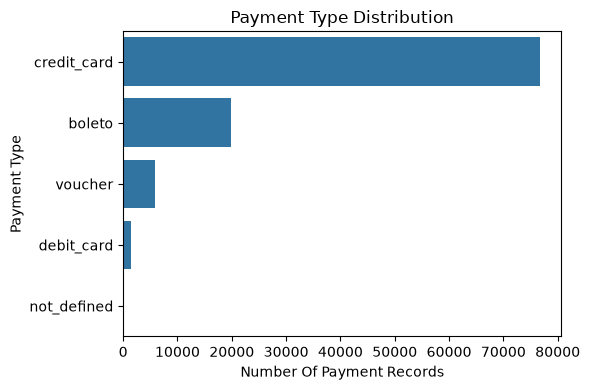

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(
    data = payments,
    y = 'payment_type',
    order = payments['payment_type'].value_counts().index
)
plt.title('Payment Type Distribution')
plt.xlabel('Number Of Payment Records')
plt.ylabel('Payment Type')
plt.tight_layout()
plt.show()

Review Analysis

In [75]:
reviews = dataset["order_reviews"]

reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

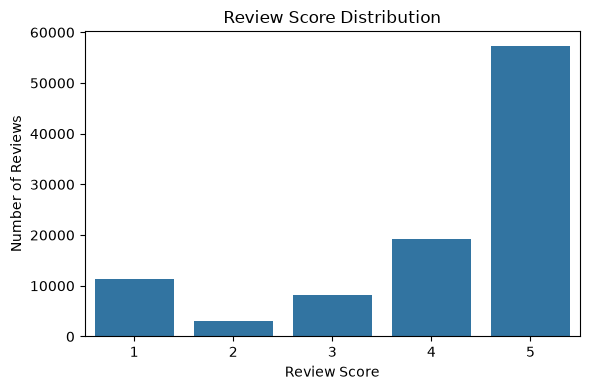

In [76]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=reviews,
    x="review_score",
    order=sorted(reviews["review_score"].dropna().unique())
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [77]:
invalidReviews = reviews[
    ~reviews["review_score"].between(1, 5)
]

print("Invalid review scores:", len(invalidReviews))

Invalid review scores: 0


In [78]:
reviews['order_id'].count()

np.int64(99224)

In [79]:
products = dataset["products"]

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


In [80]:
products["product_category_name"].nunique()

73

In [81]:
products["product_category_name"].value_counts().head(20)

product_category_name
cama_mesa_banho                      3029
esporte_lazer                        2867
moveis_decoracao                     2657
beleza_saude                         2444
utilidades_domesticas                2335
automotivo                           1900
informatica_acessorios               1639
brinquedos                           1411
relogios_presentes                   1329
telefonia                            1134
bebes                                 919
perfumaria                            868
papelaria                             849
fashion_bolsas_e_acessorios           849
cool_stuff                            789
ferramentas_jardim                    753
pet_shop                              719
eletronicos                           517
construcao_ferramentas_construcao     400
eletrodomesticos                      370
Name: count, dtype: int64

In [83]:
categoryTranslation = dataset["category_translation"]

categoryTranslation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [84]:
sellers = dataset["sellers"]

sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [85]:
sellers["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64